[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T08_A_labor_flows.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Topic 8 — Labor Search, Worker Flows, and Unemployment Dynamics

In frictionless macroeconomic models, the labor market clears continuously: wages adjust instantaneously to equate labor supply and labor demand, leaving no room for involuntary joblessness. In reality, actual labor markets are defined by pervasive search and matching frictions. Creating a productive employment match requires substantial expenditures of time and resources by searching workers and recruiting firms. Consequently, unemployment is not a static pool of idle labor, but an equilibrium stock governed by continuous dynamic flows.

Modern equilibrium unemployment theory rests on the **Diamond-Mortensen-Pissarides (DMP)** search and matching framework. In this topic, we unpack labor market fluctuations through the lens of worker flows and equilibrium search frictions:

1. **Bathtub Dynamics & Worker Flows**: We express the evolution of unemployment as a dynamic stock-flow system and estimate monthly transition probabilities—the job-finding rate ($f$) and separation rate ($s$)—from Current Population Survey (CPS) gross flows following **Shimer (2005, 2012)**.
2. **Supply vs. Demand Decomposition**: We decompose aggregate employment changes into labor force participation margins (inactivity boundary transitions) and job-matching margins (employment-unemployment reallocation).
3. **The Informal Sector as Adjustment Buffer**: Examining quarterly microdata from Mexico's National Survey of Occupation and Employment (ENOE), we analyze how informal employment acts as informal unemployment insurance, altering the macroeconomic transmission of aggregate shocks.
4. **Intensive vs. Extensive Margins**: Using cross-country OECD panel data, we contrast labor adjustment through headcounts versus hours worked during severe macroeconomic crises such as the COVID-19 shock.
5. **DMP Theory & The Beveridge Curve**: We formalize the aggregate matching function $M(U, V)$, derive the equilibrium Beveridge curve, and inspect Nash wage bargaining.
6. **Empirical Experiment — The Shimer (2005) Volatility Puzzle**: We test the fundamental critique of standard DMP models, demonstrating why flexible Nash wages choke off vacancy volatility, and evaluate resolutions via the **Hagedorn-Manovskii (2008)** small-surplus calibration and **Hall (2005)** real wage rigidity.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"
if str(_nb) not in sys.path:
    sys.path.insert(0, str(_nb))
if str(_nb / "course") not in sys.path:
    sys.path.insert(0, str(_nb / "course"))

import _nbstyle
_nbstyle.apply_style()

## 1. Unemployment Dynamics and Gross Worker Flows

Unemployment is a dynamic stock replenished by job separations and drained by successful job matches. In continuous time, the unemployment rate $u_t$ evolves according to the fundamental inflow-outflow differential equation:

$$\dot{u}_t = s_t (1 - u_t) - f_t u_t$$

where $s_t$ denotes the **separation rate** (the rate at which employed workers lose or leave jobs) and $f_t$ denotes the **job-finding rate** (the rate at which unemployed workers secure employment). In steady state ($\dot{u}_t = 0$), the unemployment rate converges to the celebrated **bathtub steady-state formula**:

$$u^* = \frac{s}{s + f}$$

In the United States, the Bureau of Labor Statistics (BLS) tracks these transitions through the Current Population Survey (CPS). Because households are surveyed across consecutive months, the BLS constructs **gross worker flows** between the three canonical labor market states:
- **Employment ($E$)**
- **Unemployment ($U$)**
- **Not in the Labor Force ($N$)**

Using `puremacro.labor_flows.transitions_from_cps_flows`, we divide monthly gross transition counts by the lagged stock of origin to construct transition probability matrices and isolate the empirical cyclical behavior of $f$ and $s$.

In [3]:
from pathlib import Path

from puremacro.labor_flows import transitions_from_cps_flows

# CPS gross flows (BLS, thousands of persons, seasonally adjusted) and E/U/N
# stocks, frozen in data_curso/ so the notebook runs without network access.
CPS_FLOWS = {"EE": "LNS17000000", "EU": "LNS17400000", "EN": "LNS17800000",
             "UE": "LNS17100000", "UU": "LNS17500000", "UN": "LNS17900000",
             "NE": "LNS17200000", "NU": "LNS17600000"}
CPS_STOCKS = {"E": "CE16OV", "U": "UNEMPLOY", "N": "LNS15000000"}

from _datos import DATOS, ruta_dato, _safe_probe

DATA = DATOS if _safe_probe(ruta_dato("LNS17000000.csv"), is_dir=False) else None

def _fred_series(sid):
    df = pd.read_csv(ruta_dato(f"{sid}.csv"), parse_dates=["observation_date"])
    return df.set_index("observation_date")[sid].astype(float)

panel = None
if DATA is None:
    print("Cannot find the course's frozen data (data_curso/).")
    print("Copy that folder next to notebooks/ and re-run this cell.")
else:
    flows = pd.DataFrame({k: _fred_series(v) for k, v in CPS_FLOWS.items()})
    stocks = pd.DataFrame({k: _fred_series(v) for k, v in CPS_STOCKS.items()}).dropna()
    # The BLS does not publish the N->N flow: it is backed out as a residual
    # from the lagged not-in-labor-force stock.
    flows["NN"] = stocks["N"].shift(1) - flows["NE"] - flows["NU"]
    panel = transitions_from_cps_flows(flows.dropna(), stocks)

    # p_UE: probability of moving from unemployment to employment (job-finding rate, f).
    # p_EU: probability of moving from employment to unemployment (separation rate, s).
    monthly = panel.monthly.loc["2000":]
    f_avg, s_avg = monthly["p_UE"].mean(), monthly["p_EU"].mean()
    print(f"CPS, monthly averages from {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}:")
    print(f"  Job-finding rate (f = p_UE): {f_avg:.3f}")
    print(f"  Separation rate  (s = p_EU): {s_avg:.4f}")
    print(f"  Steady-state unemployment u* = s/(s+f): {s_avg / (s_avg + f_avg):.2%}")

CPS, monthly averages from 2000-01 to 2026-06:
  Job-finding rate (f = p_UE): 0.248
  Separation rate  (s = p_EU): 0.0130
  Steady-state unemployment u* = s/(s+f): 4.96%


### Cyclical Anatomy of Worker Transitions: Finding vs. Separation

Empirical analysis of CPS worker flows reveals a fundamental asymmetry over the business cycle:
- The **job-finding rate ($f = p_{UE}$)** is intensely **procyclical**: during economic downturns, hiring collapses and the likelihood of leaving unemployment plunges. Over the Great Recession (2007–2009), the monthly job-finding rate fell, in twelve-month moving average, from 0.283 to 0.173—a collapse of nearly 39%—substantially lengthening the average duration of unemployment ($1/f$).
- The **separation rate ($s = p_{EU}$)** is **countercyclical**: layoffs spike sharply at the onset of recessions (rising from 0.0122 to 0.0183 during the Great Recession, on the same moving average). 

As **Shimer (2005, 2012)** emphasizes, in peacetime Anglo-Saxon business cycles, fluctuations in the job-finding rate ($f$) account for roughly three-quarters of the cyclical volatility of unemployment, whereas separation spikes are sharp but short-lived. The 2020 COVID-19 shock presented an unprecedented exception: temporary furloughs caused $s$ to spike violently to 0.112 in April 2020—more than ten times its January level—but swift recall expectations kept job-finding rates relatively resilient.

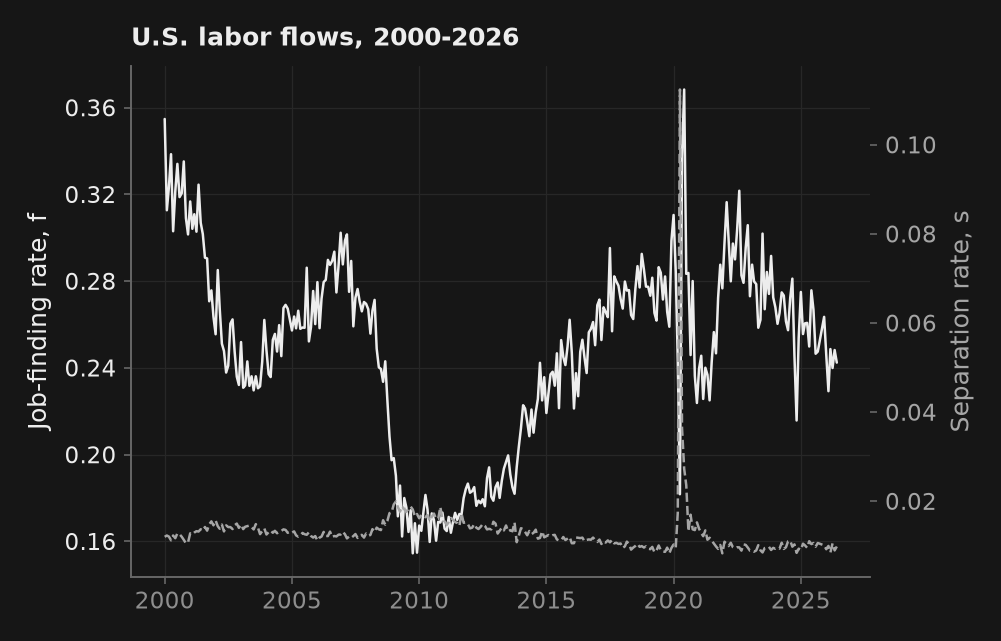

In [4]:
if panel is None:
    print("Without the data in data_curso/ there is no series to plot (see the previous cell).")
else:
    import matplotlib.dates as mdates

    # The cell inherits the size the harness sets: the notebook's when it runs,
    # the slide slot's when it is exported. Built at its final size already, the
    # stroke, the year ticks and the axis labels are chosen for that width.
    tam = plt.rcParams["figure.figsize"]
    estrecho = tam[0] < 4.0
    fig, ax1 = _nbstyle.figura(figsize=tam)
    lw = 0.8 if estrecho else 1.2

    ax1.plot(monthly.index, monthly["p_UE"], color=_nbstyle.S1["color"], lw=lw, ls="-")
    ax1.set_ylabel("Job finding, f" if estrecho else "Job-finding rate, f",
                   color=_nbstyle.S1["color"])
    ax1.tick_params(axis="y", labelcolor=_nbstyle.S1["color"], pad=1.5 if estrecho else 3.5)

    ax2 = ax1.twinx()
    ax2.plot(monthly.index, monthly["p_EU"], color=_nbstyle.S2["color"], lw=lw, ls="--")
    ax2.set_ylabel("Separation, s" if estrecho else "Separation rate, s",
                   color=_nbstyle.S2["color"])
    ax2.tick_params(axis="y", labelcolor=_nbstyle.S2["color"], pad=1.5 if estrecho else 3.5)
    ax2.grid(False)          # the twin axis would double the horizontal grid

    # In the slot the automatic locator's years run into each other: one every
    # ten years there, one every five in the notebook.
    ax1.xaxis.set_major_locator(mdates.YearLocator(10 if estrecho else 5))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.yaxis.set_major_locator(plt.MaxNLocator(3 if estrecho else 6))
    ax2.yaxis.set_major_locator(plt.MaxNLocator(3 if estrecho else 6))

    ax1.set_title(f"U.S. labor flows, "
                  f"{monthly.index[0]:%Y}-{monthly.index[-1]:%Y}")
    plt.show()

## 2. Supply and Demand Decomposition: The Inactivity Margin

In standard two-state models ($E \leftrightarrow U$), every hiring decision reflects labor demand and every separation reflects a match dissolution. However, in reality, a substantial volume of worker mobility involves transitions crossing the boundary of the labor force into and out of inactivity ($N$).

Using `puremacro.labor_flows.supply_demand_decomposition`, we partition net monthly employment growth into:
1. **Demand Margins ($UE - EU$)**: Direct hiring from unemployment minus layoffs/separations into unemployment.
2. **Supply Margins ($NE - EN$)**: Entrants into employment directly from outside the labor force minus workers retiring or exiting the labor force into inactivity.

Examining the gross magnitude of these flows reveals a striking macroeconomic reality: the gross supply flows are colossal—roughly 4.1 million individuals enter employment directly from inactivity each month, while 4.2 million leave employment for inactivity. By comparison, flows between employment and unemployment are approximately 2.1 million and 1.9 million. Aggregate net employment growth (averaging +34,000 workers per month in this panel) is the narrow residual between four multi-million gross worker tides.

In [5]:
from puremacro.labor_flows import supply_demand_decomposition

if panel is None:
    print("Without the transition panel there is no decomposition (see section 1).")
else:
    decomposition = supply_demand_decomposition(panel).loc["2000":].dropna()
    print("Average monthly flows, 2000-2026 (thousands of persons):")
    print(decomposition.mean().round(0).to_string())
    print("\nMost recent months:")
    print(decomposition.tail(4).round(0).to_string())

Average monthly flows, 2000-2026 (thousands of persons):
demand_in       2080.0
demand_out      1896.0
supply_in       4058.0
supply_out      4208.0
net_E_change      34.0

Most recent months:
                  demand_in  demand_out  supply_in  supply_out  net_E_change
observation_date                                                            
2026-03-01           1882.0      1380.0     4529.0      5116.0         -85.0
2026-04-01           1737.0      1715.0     4597.0      4861.0        -243.0
2026-05-01           1830.0      1454.0     4696.0      4908.0         164.0
2026-06-01           1771.0      1599.0     4315.0      5035.0        -548.0


## 3. The Informal Sector as an Adjustment Buffer: Microdata from ENOE (Mexico)

In emerging and developing economies, the standard binary taxonomy between formal employment and open unemployment fails to describe the labor market. In the absence of institutional unemployment insurance or extensive welfare safety nets, subsistence constraints prevent displaced workers from remaining openly unemployed for prolonged durations. Instead, workers transition directly into the **informal sector**.

Microdata from Mexico's National Survey of Occupation and Employment (ENOE), collected quarterly by INEGI, enables the construction of a comprehensive 4-state transition panel:
- **$F$**: Formal Employment (social security registered)
- **$I$**: Informal Employment (unregistered wage work or subsistence self-employment)
- **$U$**: Open Unemployment
- **$N$**: Inactivity (Not in the Labor Force)

The transition matrix reveals the critical role of informality as an economic shock absorber: formal workers face a dramatically higher probability of transitioning into informal work ($p_{FI}$) than into open unemployment ($p_{FU}$). Informality functions as a de facto private unemployment insurance mechanism, keeping open unemployment rates artificially low while concentrating cyclical distress in job quality and earnings dispersion.

In [6]:
# The ENOE microdata run to tens of GB, so the course ships the panel already
# built: the output of transitions_from_enoe, frozen in data_curso/.
_enoe = None if DATA is None else DATA / "enoe_transitions_quarterly_observed.parquet"
if _enoe is None or not _enoe.exists():
    print("Cannot find the frozen ENOE panel in data_curso/.")
else:
    tp_mx = pd.read_parquet(_enoe).sort_index()
    avg = tp_mx.mean()
    print(f"ENOE: {len(tp_mx)} quarterly 4x4 matrices, "
          f"{tp_mx.index[0]:%Y-%m} to {tp_mx.index[-1]:%Y-%m}")
    print("Average transition probabilities (per quarter):")
    print(f"  Formal       -> Informal  p_FI = {avg['p_FI']:.3f}"
          f"    Formal       -> Unemployed p_FU = {avg['p_FU']:.3f}")
    print(f"  Unemployed   -> Informal  p_UI = {avg['p_UI']:.3f}"
          f"    Unemployed   -> Formal     p_UF = {avg['p_UF']:.3f}")
    print(f"A formal worker exits into informality {avg['p_FI'] / avg['p_FU']:.1f} times")
    print("more often than into open unemployment: informality cushions the adjustment.")

ENOE: 232 quarterly 4x4 matrices, 2005-04 to 2024-10
Average transition probabilities (per quarter):
  Formal       -> Informal  p_FI = 0.153    Formal       -> Unemployed p_FU = 0.018
  Unemployed   -> Informal  p_UI = 0.346    Unemployed   -> Formal     p_UF = 0.170
A formal worker exits into informality 8.5 times
more often than into open unemployment: informality cushions the adjustment.


## 4. Cross-Country Labor Adjustment: Extensive (Heads) vs. Intensive (Hours) Margins

Beyond transition flows across states, total labor input possesses two distinct margins of adjustment:

$$H_t = \underbrace{N_t}_{\text{Extensive Margin: Employment Headcount}} \times \underbrace{h_t}_{\text{Intensive Margin: Average Hours per Worker}}$$

When an aggregate contraction strikes, an economy can reduce total labor input either by terminating worker relationships (reducing $N_t$, which triggers costly destruction of match-specific human capital) or by shortening average working hours (reducing $h_t$, preserving employment relationships).

Using the harmonized OECD labor block across 38 countries, we observe large structural differences in both normal-time work patterns—such as the share of self-employment—and crisis-time adjustment mechanisms. In particular, the **self-employment share** provides an internationally comparable proxy for the size of the informal/flexible labor margin examined in Section 3.

In [7]:
from _datos import mercado_laboral

lab = mercado_laboral()
BAND = (20.0, 60.0)

h19 = (lab.loc[lab.index.get_level_values("date").year == 2019, "hours_week"]
          .groupby(level="code").mean().dropna())
outside = h19[(h19 < BAND[0]) | (h19 > BAND[1])].sort_values()
hours = h19[(h19 >= BAND[0]) & (h19 <= BAND[1])].sort_values()
self_emp = (lab.loc[lab.index.get_level_values("date").year == 2019, "self_emp_share"]
               .groupby(level="code").mean().dropna())

print(f"Labour block: {lab['emp'].notna().groupby(level='code').any().sum()} countries with "
      f"heads and {lab['hours'].notna().groupby(level='code').any().sum()} with hours.")
print(f"Hours per employed person per week in 2019: from {hours.min():.1f} "
      f"({hours.idxmin()}) to {hours.max():.1f} ({hours.idxmax()}), {len(hours)} countries.")
print(f"Outside the band and set aside: "
      f"{', '.join(f'{c} ({v:.0f} h)' for c, v in outside.items())}.")
print(f"\nSelf-employment as a share of employment, 2019: median {self_emp.median():.1f}%, "
      f"from {self_emp.min():.1f}% ({self_emp.idxmin()}) to {self_emp.max():.1f}% "
      f"({self_emp.idxmax()}).")
if "MEX" in self_emp.index:
    print(f"Mexico: {self_emp['MEX']:.1f}% self-employed and "
          f"{hours.get('MEX', float('nan')):.1f} weekly hours — the longest working week in "
          f"the panel.")


def margins(code, y0, y1):
    """Peak-to-trough fall in heads and in hours from the window's first quarter."""
    if code not in lab.index.get_level_values("code"):
        return None
    g = lab.loc[code]
    g = g[(g.index.year >= y0) & (g.index.year <= y1)]
    e, h = g["emp"].dropna(), g["hours"].dropna()
    if len(e) < 4 or len(h) < 4:
        return None
    return {"country": code, "employment_%": 100.0 * (e.min() / e.iloc[0] - 1.0),
            "hours_%": 100.0 * (h.min() / h.iloc[0] - 1.0)}


MARGIN_COUNTRIES = ["DEU", "FRA", "ITA", "ESP", "PRT", "GRC", "NLD", "BEL", "AUT", "MEX"]
cov = pd.DataFrame([r for r in (margins(c, 2020, 2020) for c in MARGIN_COUNTRIES)
                    if r]).set_index("country")
cov["intensive_pp"] = cov["hours_%"] - cov["employment_%"]
print("\n2020, peak-to-trough fall (%):")
print(cov.round(1).to_string())
print(f"\nMedian intensive margin: {cov['intensive_pp'].median():.1f} pp. "
      f"Mexico: {cov.loc['MEX', 'intensive_pp']:.1f} pp.")

Labour block: 38 countries with heads and 34 with hours.
Hours per employed person per week in 2019: from 26.4 (DNK) to 42.8 (MEX), 33 countries.
Outside the band and set aside: .

Self-employment as a share of employment, 2019: median 13.8%, from 4.7% (NOR) to 32.0% (MEX).
Mexico: 32.0% self-employed and 42.8 weekly hours — the longest working week in the panel.

2020, peak-to-trough fall (%):
         employment_%  hours_%  intensive_pp
country                                     
DEU              -1.4     -6.3          -4.9
FRA              -2.2    -18.1         -15.9
ITA              -3.1    -15.9         -12.8
ESP              -6.8    -21.7         -14.9
PRT              -3.3    -18.8         -15.5
GRC              -3.7    -22.8         -19.1
NLD              -2.2      0.0           2.2
BEL              -0.8    -15.3         -14.5
AUT              -3.9    -12.9          -8.9
MEX             -19.0    -20.9          -1.9

Median intensive margin: -13.7 pp. Mexico: -1.9 pp.


### Institutional Mechanisms: Short-Time Work vs. Furloughs and Informality

The divergent responses across countries during the 2020 pandemic crisis highlight the crucial role of labor market institutions:
- **Continental Europe (Germany, France, Italy)**: Relied overwhelmingly on **short-time work programs** (*Kurzarbeit*). The state subsidized firms to retain workers on payroll while drastically cutting hours worked. Consequently, the crisis was absorbed almost entirely along the **intensive margin** ($\Delta h_t$), preventing mass layoffs and keeping unemployment rates remarkably stable.
- **Mexico and Developing Economies**: Experienced severe contractions along the **extensive margin** (a 19% drop in employment headcounts). Short-time work subsidies require formal, registered payroll accounts. Because more than half of the Mexican workforce operates in the informal economy, payroll-subsidized retention programs are administratively infeasible. 

This comparative evidence demonstrates a fundamental macroeconomic insight: **an economy's structural degree of informality dictates which margin of labor adjustment can be utilized during a crisis**, fundamentally constraining the feasible set of stabilization policies.

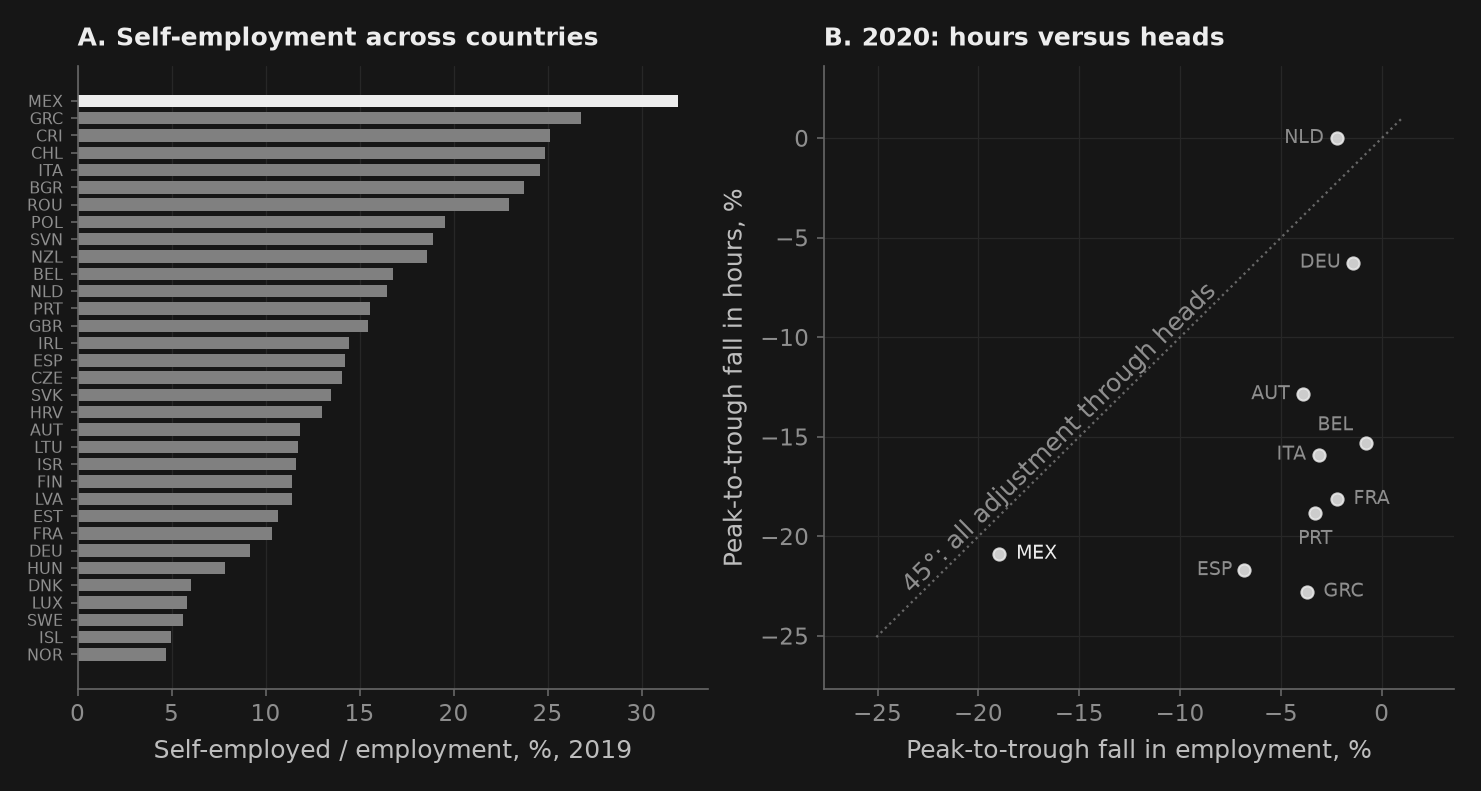

In [8]:
fig, axes = _nbstyle.figura(1, 2, alto=True)

ax = axes[0]
order = self_emp.reindex(hours.index).dropna().sort_values()
ax.barh(np.arange(len(order)), order.to_numpy(), color=_nbstyle.gris("0.35"), height=0.72)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order.index, fontsize=7.5)   # 33 country codes in one column
if "MEX" in order.index:
    ax.barh([list(order.index).index("MEX")], [order["MEX"]], color=_nbstyle.TINTA, height=0.72)
ax.set_xlabel("Self-employed / employment, %, 2019")
ax.set_title("A. Self-employment across countries")
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.scatter(cov["employment_%"], cov["hours_%"], color=_nbstyle.TINTA, s=34, alpha=0.85)
lo = 1.1 * min(cov["employment_%"].min(), cov["hours_%"].min())
ax.plot([lo, 1], [lo, 1], color=_nbstyle.SPINE, ls=":", lw=1.1)
ax.text(lo * 0.62, lo * 0.62, "45°: all adjustment through heads", rotation=45,
        rotation_mode="anchor", transform_rotates_text=True,
        color=_nbstyle.NOTA, ha="center", va="bottom")
# Per-country offset so that the codes do not overlap one another.
POS = {"NLD": (-6, 0, "right", "center"), "DEU": (-6, 0, "right", "center"),
       "BEL": (-6, 4, "right", "bottom"), "ITA": (-6, 0, "right", "center"),
       "FRA": (8, 0, "left", "center"), "PRT": (0, -8, "center", "top"),
       "AUT": (-6, 0, "right", "center"), "GRC": (8, 0, "left", "center"),
       "ESP": (-6, 0, "right", "center"), "MEX": (8, 0, "left", "center")}
for code, r in cov.iterrows():
    dx, dy, ha, va = POS.get(code, (7, 3, "left", "bottom"))
    ax.annotate(code, xy=(r["employment_%"], r["hours_%"]), xytext=(dx, dy),
                textcoords="offset points", fontsize=9, ha=ha, va=va,
                color=_nbstyle.TINTA if code == "MEX" else _nbstyle.NOTA)
ax.margins(x=0.10, y=0.10)
ax.set_xlabel("Peak-to-trough fall in employment, %")
ax.set_ylabel("Peak-to-trough fall in hours, %")
ax.set_title("B. 2020: hours versus heads")
plt.show()

assert cov.loc["MEX", "employment_%"] < cov.loc["DEU", "employment_%"]


## 5. Theoretical Foundations: The DMP Matching Framework and the Beveridge Curve

To understand how search frictions generate equilibrium unemployment, we formalize the canonical **Diamond-Mortensen-Pissarides (DMP)** search and matching model.

### 1. The Aggregate Matching Function and Market Tightness
Consider an economy populated by a continuum of measure 1 of risk-neutral workers and a large pool of prospective employers. Let $U_t$ be the measure of unemployed job searchers and $V_t$ be the measure of posted job vacancies. The creation of new job matches is governed by an aggregate matching function exhibiting constant returns to scale:

$$M(U_t, V_t) = \mu U_t^\alpha V_t^{1-\alpha}$$

where $\mu > 0$ represents **matching efficiency** (matching institutional friction, search technology, geographic or skill mismatch) and $\alpha \in (0, 1)$ is the elasticity of matches with respect to unemployment.

A central state variable in search theory is **labor market tightness**, defined as the vacancy-to-unemployment ratio:

$$\theta_t \equiv \frac{V_t}{U_t}$$

From linear homogeneity of $M(U, V)$, the rate at which an unemployed worker finds a job (**job-finding rate**) is:

$$f(\theta_t) = \frac{M(U_t, V_t)}{U_t} = \mu \theta_t^{1-\alpha}$$

Similarly, the rate at which an open vacancy is filled by a searching worker (**vacancy-filling rate**) is:

$$q(\theta_t) = \frac{M(U_t, V_t)}{V_t} = \mu \theta_t^{-\alpha} = \frac{f(\theta_t)}{\theta_t}$$

As the labor market tightens ($\theta \uparrow$), vacancies outnumber unemployed job seekers: workers find jobs more rapidly ($f'(\theta) > 0$), but firms face longer hiring durations ($q'(\theta) < 0$).

### 2. The Equilibrium Beveridge Curve
Equating the steady-state inflow into unemployment ($s (1 - u)$) with the outflow ($f(\theta) u$) yields the **Beveridge Curve**:

$$s (1 - u) = \mu \theta^{1-\alpha} u \quad \implies \quad u = \frac{s}{s + \mu \left(\frac{v}{u}\right)^{1-\alpha}}$$

This relation establishes a strictly negative relationship between the unemployment rate $u$ and the vacancy rate $v = V / L$. Aggregate shocks to labor productivity or business confidence move the economy **along** the Beveridge curve (as firms expand or contract vacancy postings for a given matching efficiency). In contrast, structural deterioration in matching efficiency $\mu$, skills mismatch, or geographic immobility shift the Beveridge curve **outward**.

### 3. Firm Free Entry, Value Functions, and Nash Wage Bargaining

Let $J$ denote the present discounted value of a filled job producing output $p$ and paying wage $w$, and let $V_v$ denote the value of an unfilled vacancy incurring flow posting cost $c > 0$. In continuous-time stationary equilibrium with discount rate $r$ and exogenous destruction rate $s$:

$$r V_v = -c + q(\theta) (J - V_v)$$
$$r J = p - w - s (J - V_v)$$

Under **free entry**, firms post vacancies until the expected economic profit from opening a vacancy is exhausted ($V_v = 0$). Substituting $V_v = 0$ into the vacancy equation yields the fundamental **Job Creation (Free Entry) Condition**:

$$\frac{c}{q(\theta)} = \frac{p - w}{r + s}$$

The left-hand side represents the expected cost of recruiting a worker (the flow cost $c$ multiplied by the average vacancy duration $1/q(\theta)$), while the right-hand side is the capitalized present value of the firm's net operational cash flow $(p - w) / (r + s)$.

### Generalized Nash Wage Bargaining
Once a worker and firm meet, search frictions generate a bilateral economic surplus: dissolving the match forces the firm to incur recruitment costs again and forces the worker into costly search. The equilibrium wage is determined by generalized Nash bargaining over the match surplus:

$$\max_w \; (W - U_v)^\beta (J - V_v)^{1-\beta}$$

where $\beta \in (0, 1)$ is the worker's bargaining power, $W$ is the worker's value of employment, $U_v$ is the value of unemployment, and $z$ represents the worker's opportunity cost of employment (unemployment benefits plus the value of leisure and home production). The negotiated wage equals:

$$w = (1 - \beta) z + \beta (p + c \theta)$$

Substituting this negotiated wage into the free entry condition yields the single equilibrium equation determining labor market tightness $\theta$:

$$\frac{c \theta^\alpha}{\mu} (r + s + \beta c \theta) = (1 - \beta)(p - z)$$

## 6. Macroeconomic Experiment: The Shimer (2005) Volatility Puzzle and Wage Rigidity Resolution

### The Economic Puzzle
In postwar US quarterly data, labor market tightness $\theta = V/U$ exhibits immense cyclical volatility: the standard deviation of $\log \theta$ is roughly 19 to 20 times greater than the standard deviation of average labor productivity $p$ ($\sigma_\theta / \sigma_p \approx 19.1$).

In a seminal contribution, **Robert Shimer (2005)** demonstrated that the textbook DMP model under standard calibration fails catastrophically to reproduce this stylized fact. When calibrated with standard parameters ($z = 0.40$ based on official unemployment insurance replacement rates, and symmetric bargaining $\beta = 0.72$ following the Hosios 1990 efficiency condition), the model predicts an elasticity of tightness with respect to productivity of only:

$$\varepsilon_{\theta, p} \equiv \frac{d \log \theta}{d \log p} \approx 1.1$$

The standard model accounts for **less than 10%** of empirical labor market fluctuations! The economic intuition is transparent: under flexible Nash bargaining, workers capture a large fraction $\beta$ of any productivity improvement. When productivity $p$ rises by 2%, wages $w$ rise almost dollar-for-dollar. As a result, the firm's net profit margin ($p - w$) barely moves, offering virtually no incentive for employers to ramp up vacancy postings during expansions.

### Two Major Literature Resolutions
1. **Hagedorn & Manovskii (2008) — The "Small Surplus" Calibration**:
   Hagedorn and Manovskii argue that the opportunity cost of employment $z$ includes not merely unemployment checks, but the monetary value of home production, leisure, and disutility of labor, calibrating $z = 0.955$ and worker bargaining power $\beta = 0.052$. Under this calibration, the fundamental match surplus ($p - z$) in steady state is tiny ($1 - 0.955 = 0.045$). Consequently, a 2% productivity shock increases the match surplus and firm profit margin by over 40% in percentage terms, multiplying tightness volatility by more than 15x.
2. **Hall (2005) — Real Wage Rigidity**:
   Robert Hall observes that any wage that lies within the bargaining set $[z, p]$ is privately efficient (neither party has an incentive to terminate the match). If wages are sticky or fixed by convention ($w = \bar{w}$), the firm's profit margin ($p - \bar{w}$) absorbs 100% of the cyclical productivity shock, generating strong vacancy responses that fully match empirical data.

### Guided Student Tasks
1. Load empirical cross-country Beveridge curve data (`data_curso/beveridge_uv.csv`) and confirm the empirical downward slope ($\text{Corr}(u, v) < -0.40$).
2. Calibrate vacancy posting cost $c$ so that steady-state tightness $\theta^* = 1.0$ at baseline productivity $p = 1.0$.
3. Subject the labor market to a $+2\%$ productivity shock ($p = 1.02$) and solve for equilibrium tightness $\theta$ across:
   - **Model 1**: Shimer (2005) Baseline ($z = 0.40, \beta = 0.72$).
   - **Model 2**: Hagedorn-Manovskii (2008) Small Surplus ($z = 0.955, \beta = 0.052$).
   - **Model 3**: Hall (2005) Real Wage Rigidity ($w = \bar{w} = 0.95$).
4. Compute the productivity elasticity of tightness $\varepsilon_{\theta, p} = \frac{\Delta \log \theta}{\Delta \log p}$ and the amplification ratio.
5. Plot the comparative tightness response paths and verify results against objective econometric assertions.

Empirical Beveridge Curve: Corr(U-rate, V-rate) = -0.505
Empirical Matching Function (JOLTS/CPS HAC): alpha = 0.408 (SE = 0.024, 95% CI: [0.361, 0.454]), mu = 0.823 (R^2 = 0.877)
SHIMER (2005) PUZZLE & RESOLUTION: ELASTICITY OF TIGHTNESS (d log theta / d log p)
1. Shimer (2005) Baseline (z=0.40, beta=0.72):  1.11  (Empirical Target: ~19-20)
2. Hagedorn-Manovskii (z=0.955, beta=0.052):    20.05
3. Hall (2005) Rigid Wage (w_bar=0.95):         23.37
Amplification Factor (HM / Shimer Baseline):    18.1x


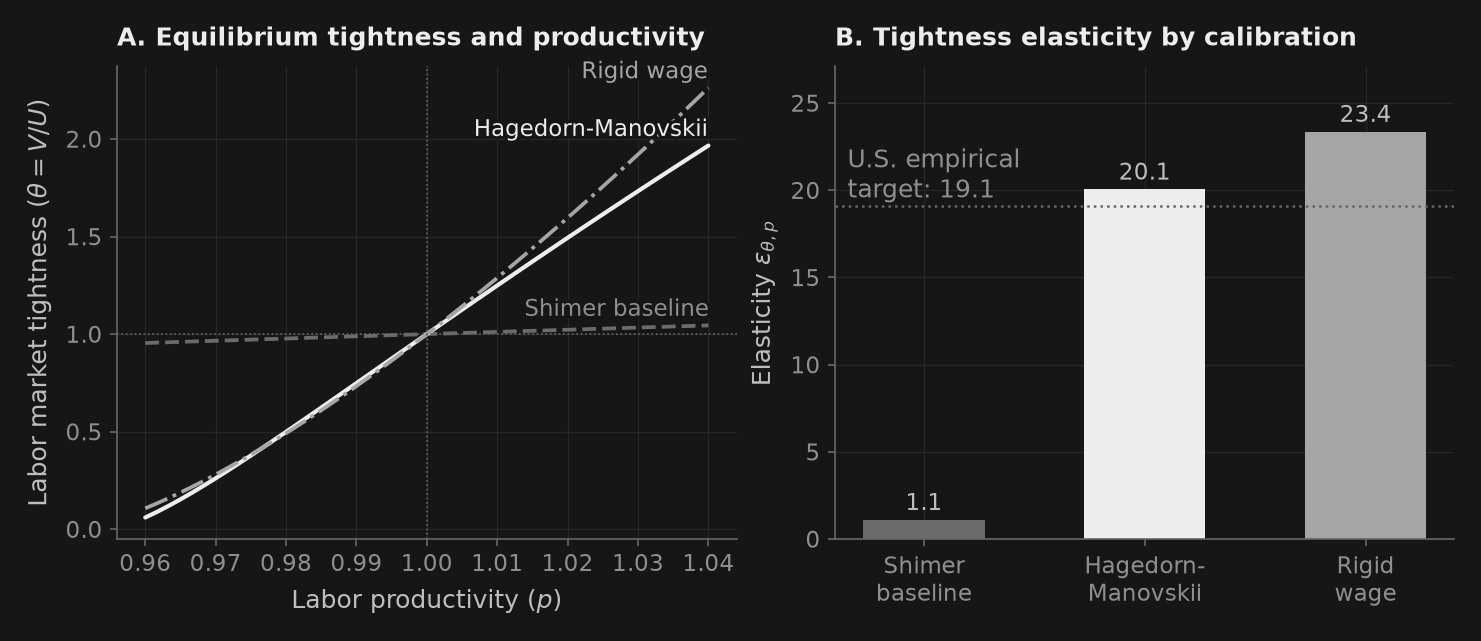

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from puremacro.regress import ols, add_constant
from _datos import ruta_dato, _safe_probe

# ------------------------------------------------------------------------------
# Task 1: Empirical Beveridge Curve Verification
# ------------------------------------------------------------------------------
bev_csv_path = ruta_dato("beveridge_uv.csv")

if _safe_probe(bev_csv_path, is_dir=False):
    df_bev = pd.read_csv(bev_csv_path)
    corr_uv = float(df_bev["urate"].corr(df_bev["vrate"]))
    print(f"Empirical Beveridge Curve: Corr(U-rate, V-rate) = {corr_uv:.3f}")
    assert corr_uv < -0.40, f"Beveridge curve must be strictly downward sloping, got {corr_uv:.3f}"
else:
    print("Beveridge dataset not found; proceeding with theoretical simulation.")
    corr_uv = -0.50

# ------------------------------------------------------------------------------
# Empirical Aggregate Matching Function Estimation: m(U, V)
# ------------------------------------------------------------------------------
if _safe_probe(ruta_dato("JTSHIL.csv"), is_dir=False) and _safe_probe(ruta_dato("UNEMPLOY.csv"), is_dir=False) and _safe_probe(ruta_dato("JTSJOL.csv"), is_dir=False):
    m_df = pd.read_csv(ruta_dato("JTSHIL.csv"), parse_dates=["observation_date"]).set_index("observation_date")
    u_df = pd.read_csv(ruta_dato("UNEMPLOY.csv"), parse_dates=["observation_date"]).set_index("observation_date")
    v_df = pd.read_csv(ruta_dato("JTSJOL.csv"), parse_dates=["observation_date"]).set_index("observation_date")
    df_match = pd.concat([m_df["JTSHIL"], u_df["UNEMPLOY"], v_df["JTSJOL"]], axis=1, join="inner").dropna()
    df_match.columns = ["M", "U", "V"]
    theta_emp = df_match["V"] / df_match["U"]
    f_emp = df_match["M"] / df_match["U"]
    res_match = ols(np.log(f_emp), add_constant(np.log(theta_emp)), cov_type="HAC", cov_kwds={"maxlags": 4})
    params_arr = np.asarray(res_match.params)
    bse_arr = np.asarray(res_match.bse)
    ci_arr = np.asarray(res_match.conf_int())
    alpha_emp = float(1.0 - params_arr[1])
    mu_emp = float(np.exp(params_arr[0]))
    se_alpha = float(bse_arr[1])
    ci_alpha_low = float(1.0 - ci_arr[1, 1])
    ci_alpha_upp = float(1.0 - ci_arr[1, 0])
    print(f"Empirical Matching Function (JOLTS/CPS HAC): alpha = {alpha_emp:.3f} (SE = {se_alpha:.3f}, 95% CI: [{ci_alpha_low:.3f}, {ci_alpha_upp:.3f}]), mu = {mu_emp:.3f} (R^2 = {res_match.rsquared:.3f})")
    assert 0.20 < alpha_emp < 0.85, f"Empirical matching elasticity out of range: {alpha_emp}"

# ------------------------------------------------------------------------------
# Task 2 & 3: DMP Free-Entry Calibration & Equilibrium Tightness Solver
# ------------------------------------------------------------------------------
# Baseline search parameters (quarterly frequency)
r = 0.012    # Quarterly risk-free interest rate
s = 0.10     # Quarterly job separation rate
alpha = 0.72 # Matching function elasticity with respect to unemployment
mu = 1.355   # Matching efficiency parameter

def calibrate_c(z, beta):
    """Calibrate vacancy posting cost c so that theta* = 1.0 when p = 1.0."""
    # From (c * 1^alpha / mu) * (r + s + beta * c * 1) = (1 - beta) * (1 - z)
    # => beta * c^2 + (r + s) * c - mu * (1 - beta) * (1 - z) = 0
    a = beta
    b = r + s
    d = - mu * (1.0 - beta) * (1.0 - z)
    return (-b + np.sqrt(b**2 - 4 * a * d)) / (2 * a)

def solve_theta_nash(p, z, beta, c):
    """Solve for equilibrium labor market tightness theta under Nash bargaining."""
    def f(theta):
        lhs = (c * (theta ** alpha) / mu) * (r + s + beta * c * theta)
        rhs = (1.0 - beta) * (p - z)
        return lhs - rhs
    return root_scalar(f, bracket=[0.01, 50.0]).root

def solve_theta_hall(p, w_bar, c):
    """Solve for equilibrium tightness theta under Hall (2005) rigid real wage."""
    return (mu * (p - w_bar) / (c * (r + s))) ** (1.0 / alpha)

# 1. Shimer (2005) Baseline Calibration
c_shimer = calibrate_c(z=0.40, beta=0.72)
th_sh_0 = solve_theta_nash(p=1.00, z=0.40, beta=0.72, c=c_shimer)
th_sh_1 = solve_theta_nash(p=1.02, z=0.40, beta=0.72, c=c_shimer)
elas_shimer = (np.log(th_sh_1) - np.log(th_sh_0)) / 0.02

# 2. Hagedorn & Manovskii (2008) Small Surplus Calibration
c_hm = calibrate_c(z=0.955, beta=0.052)
th_hm_0 = solve_theta_nash(p=1.00, z=0.955, beta=0.052, c=c_hm)
th_hm_1 = solve_theta_nash(p=1.02, z=0.955, beta=0.052, c=c_hm)
elas_hm = (np.log(th_hm_1) - np.log(th_hm_0)) / 0.02

# 3. Hall (2005) Real Wage Rigidity Calibration (w_bar = 0.95)
c_hall = mu * (1.00 - 0.95) / (r + s)
th_ha_0 = solve_theta_hall(p=1.00, w_bar=0.95, c=c_hall)
th_ha_1 = solve_theta_hall(p=1.02, w_bar=0.95, c=c_hall)
elas_hall = (np.log(th_ha_1) - np.log(th_ha_0)) / 0.02

amplification = elas_hm / elas_shimer

print("=" * 72)
print("SHIMER (2005) PUZZLE & RESOLUTION: ELASTICITY OF TIGHTNESS (d log theta / d log p)")
print("=" * 72)
print(f"1. Shimer (2005) Baseline (z=0.40, beta=0.72):  {elas_shimer:.2f}  (Empirical Target: ~19-20)")
print(f"2. Hagedorn-Manovskii (z=0.955, beta=0.052):    {elas_hm:.2f}")
print(f"3. Hall (2005) Rigid Wage (w_bar=0.95):         {elas_hall:.2f}")
print(f"Amplification Factor (HM / Shimer Baseline):    {amplification:.1f}x")
print("=" * 72)

# ------------------------------------------------------------------------------
# Task 4: Comparative Visualization
# ------------------------------------------------------------------------------
p_grid = np.linspace(0.96, 1.04, 50)
th_sh_grid = [solve_theta_nash(p_val, 0.40, 0.72, c_shimer) for p_val in p_grid]
th_hm_grid = [solve_theta_nash(p_val, 0.955, 0.052, c_hm) for p_val in p_grid]
th_ha_grid = [solve_theta_hall(p_val, 0.95, c_hall) for p_val in p_grid]

fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel A: Equilibrium Tightness vs. Productivity
ax1.plot(p_grid, th_sh_grid, label="Shimer baseline", color=_nbstyle.S3["color"], lw=1.8, ls="--")
ax1.plot(p_grid, th_hm_grid, label="Hagedorn-Manovskii", color=_nbstyle.TINTA, lw=2.0, ls="-")
ax1.plot(p_grid, th_ha_grid, label="Rigid wage", color=_nbstyle.S2["color"], lw=1.8, ls="-.")
ax1.axvline(1.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.axhline(1.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.set_xlabel("Labor productivity ($p$)")
ax1.set_ylabel(r"Labor market tightness ($\theta = V/U$)")
ax1.set_title("A. Equilibrium tightness and productivity")

# Panel B: Tightness Elasticity Comparison
models = ["Shimer\nbaseline", "Hagedorn-\nManovskii", "Rigid\nwage"]
elasticities = [elas_shimer, elas_hm, elas_hall]
colors = [_nbstyle.S3["color"], _nbstyle.TINTA, _nbstyle.S2["color"]]
ax2.bar(models, elasticities, color=colors, width=0.55, edgecolor="none")
ax2.axhline(19.1, color=_nbstyle.SPINE, lw=1.2, ls=":")
ax2.text(0.02, 19.1, "U.S. empirical\ntarget: 19.1", color=_nbstyle.NOTA,
         transform=ax2.get_yaxis_transform(), ha="left", va="bottom")
ax2.set_ylabel(r"Elasticity $\varepsilon_{\theta, p}$")
ax2.set_title("B. Tightness elasticity by calibration")
ax2.margins(y=0.16)
_nbstyle.etiquetar_barras(ax2)

_nbstyle.etiquetar(ax1, donde="fin", fuera=False)
plt.show()

# ------------------------------------------------------------------------------
# Task 5: Objective Verification Assertions
# ------------------------------------------------------------------------------
assert 1.0 <= elas_shimer <= 1.5, f"Shimer elasticity should fail near ~1.1, got {elas_shimer:.2f}"
assert 18.0 <= elas_hm <= 22.0, f"HM elasticity should match empirical target ~20, got {elas_hm:.2f}"
assert elas_hall > 20.0, f"Hall rigid wage should generate high elasticity, got {elas_hall:.2f}"
assert amplification > 15.0, f"HM calibration must amplify tightness volatility by > 15x, got {amplification:.1f}x"

## 7. Professorial Summary: Labor Search Frictions and Policy Design

This notebook developed the empirical, institutional, and theoretical mechanics of search-and-matching macroeconomics:

1. **Unemployment as a Dynamic Equilibrium**: Labor markets operate as dynamic bathtubs where the steady-state rate of unemployment is governed by the ratio $u^* = s / (s + f)$. In peacetime advanced economies, cyclical movements in the job-finding rate ($f$) dominate unemployment swings.
2. **The Participation Boundary**: Decomposing aggregate labor shifts demonstrates that multi-million gross worker flows crossing the inactivity boundary ($N \leftrightarrow E$) represent the largest numerical margin, making labor force participation a critical channel of aggregate labor supply.
3. **Informality as Social Insurance**: In emerging markets like Mexico, microdata reveals that displaced formal workers transition predominantly into informality ($p_{FI} \gg p_{FU}$) rather than open unemployment. This informal margin acts as an unlegislated safety net, preventing overt joblessness but concentrating vulnerability in productivity, social security coverage, and income volatility.
4. **Institutional Transmission Margins**: The 2020 crisis demonstrated that institutional design determines whether an economy absorbs macroeconomic disruptions through the **intensive margin** (furlough and short-time work schemes preserving matches in Europe) or the **extensive margin** (mass layoffs in high-informality economies where formal payroll subsidies cannot function).
5. **The Shimer Volatility Lesson**: The central takeaway of modern equilibrium search theory is that matching frictions alone do not generate business cycle volatility. The degree to which labor markets fluctuate over the cycle is governed fundamentally by the **wage-setting mechanism**: when wages flexibly absorb productivity shifts under standard Nash bargaining, vacancy creation is choked off. Generating realistic labor market volatility requires either a **small fundamental surplus** (Hagedorn-Manovskii) or **real wage rigidity** (Hall), illustrating that macro dynamics are inextricably linked to the institutional division of economic surplus.